In [17]:
import duckdb

conn = duckdb.connect(database="../credit_risk_warehouse.db", read_only=True)
print(" Successfully reconnected to the analytical data warehouse!")

 Successfully reconnected to the analytical data warehouse!


In [18]:
risk_analysis_df = conn.execute("""
    SELECT 
        CASE 
            WHEN AMT_INCOME_TOTAL < 100000 THEN 'Low Income (<100k)'
            WHEN AMT_INCOME_TOTAL BETWEEN 100000 AND 200000 THEN 'Medium Income (100k-200k)'
            ELSE 'High Income (>200k)'
        -- AS creates a clear custom header name for our bucketed group column
        END AS income_segment,
        
        COUNT(*) AS total_applicants,
        SUM(TARGET) AS total_defaulters,
        
        -- Calculating the mathematical percentage rate of defaults per group
        ROUND(AVG(TARGET) * 100, 2) AS default_rate_percentage

    FROM mart_applicant_features
    GROUP BY income_segment
    ORDER BY default_rate_percentage DESC;
""").df()

# Displays the resulting data table matrix on the screen
risk_analysis_df

,income_segment,total_applicants,total_defaulters,default_rate_percentage
0,Medium Income (100k-200k),155898,13326.0,8.55
1,Low Income (<100k),63698,5225.0,8.20
2,High Income (>200k),87915,6274.0,7.14


In [30]:
# Pulling raw columns directly from the analytical data warehouse mart
df_plots = conn.execute("""
    SELECT TARGET, credit_income_ratio, AMT_INCOME_TOTAL, AMT_CREDIT
    FROM mart_applicant_features
""").df()

In [31]:
ml_data = df_plots.copy()  # Creates a copy of the DataFrame for further analysis

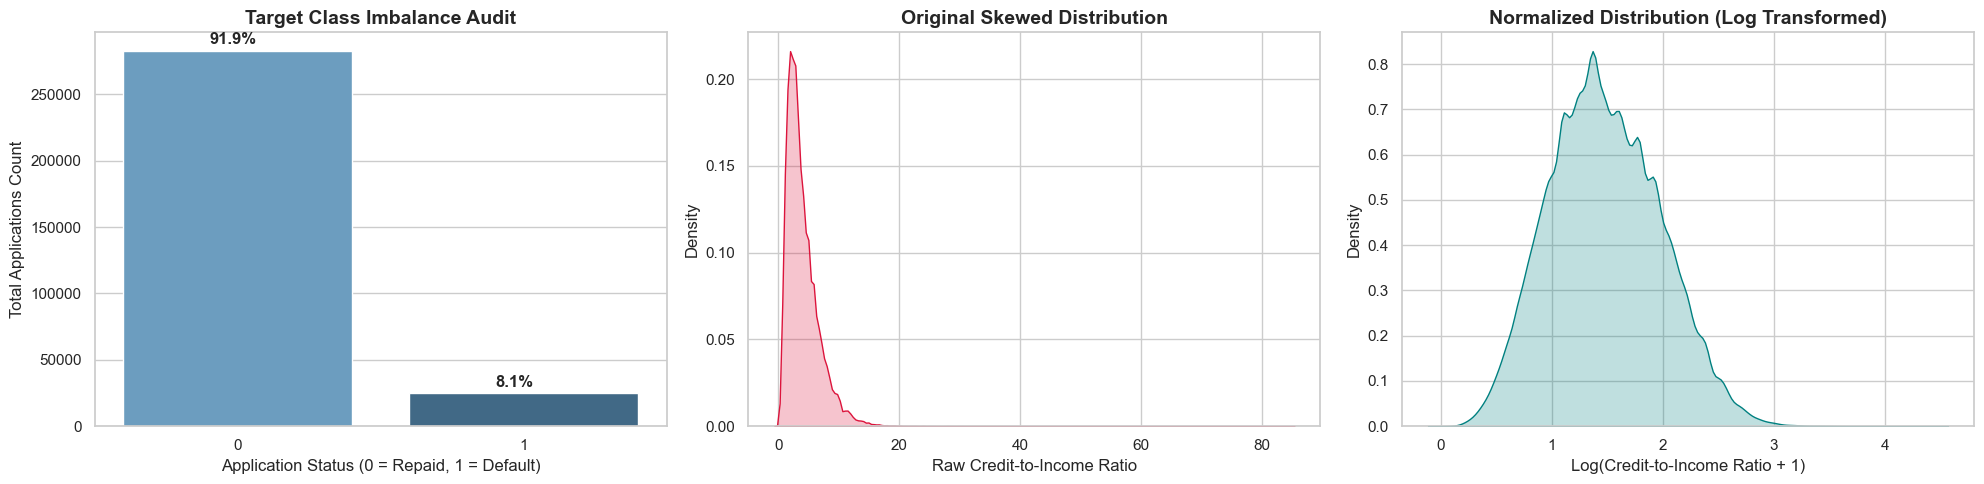

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

active_df = df_plots

# This sets the visualization style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# ==========================================
# PLOT 1: TARGET IMBALANCE
# ==========================================
sns.countplot(
    x='TARGET', 
    data=active_df, 
    ax=axes[0], 
    hue='TARGET',
    palette='Blues_d',
    legend = False
)
axes[0].set_title('Target Class Imbalance Audit', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Application Status (0 = Repaid, 1 = Default)', fontsize=12)
axes[0].set_ylabel('Total Applications Count', fontsize=12)

total = len(active_df)
for p in axes[0].patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    axes[0].annotate(percentage, (p.get_x() + 0.3, p.get_height() + 5000), fontsize=12, fontweight='bold')

# ==========================================
# PLOT 2: BEFORE CORRECTION
# ==========================================
sns.kdeplot(
    active_df['credit_income_ratio'], 
    ax=axes[1], 
    color='crimson', 
    fill=True
)
axes[1].set_title('Original Skewed Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Raw Credit-to-Income Ratio', fontsize=12)

# ==========================================
# PLOT 3: AFTER CORRECTION
# ==========================================
# Apply log transformation to handle high-leverage outliers gracefully
active_df['log_credit_income_ratio'] = np.log1p(active_df['credit_income_ratio'])

sns.kdeplot(
    active_df['log_credit_income_ratio'], 
    ax=axes[2], 
    color='teal', 
    fill=True
)
axes[2].set_title('Normalized Distribution (Log Transformed)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Log(Credit-to-Income Ratio + 1)', fontsize=12)

plt.tight_layout()
plt.show()

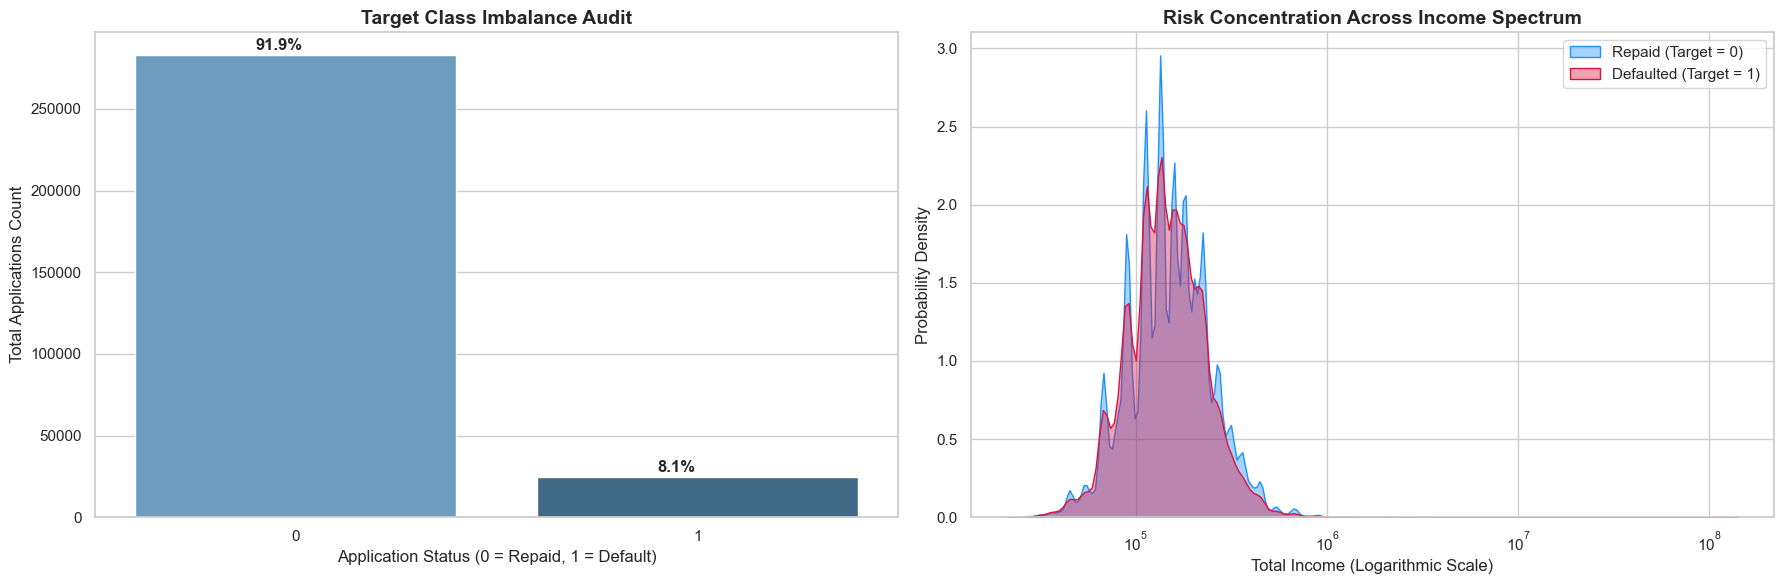

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. This will Set up a clean, professional canvas with two side-by-side plots
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ==========================================================
# PLOT 1: THE TARGET CLASS IMBALANCE AUDIT
# ==========================================================
sns.countplot(
    x='TARGET', 
    data=ml_data, 
    hue='TARGET',  # Sets colors per category cleanly
    palette='Blues_d',
    legend=False,
    ax=axes[0]
)

# Adds dynamic percentage text labels on top of each bar
total_applicants = len(ml_data)
for p in axes[0].patches:
    percentage = f'{100 * p.get_height() / total_applicants:.1f}%'
    axes[0].annotate(
        percentage, 
        (p.get_x() + 0.3, p.get_height() + (total_applicants * 0.01)), 
        fontsize=12, 
        fontweight='bold'
    )

axes[0].set_title('Target Class Imbalance Audit', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Application Status (0 = Repaid, 1 = Default)', fontsize=12)
axes[0].set_ylabel('Total Applications Count', fontsize=12)

# ==========================================================
# PLOT 2: RISK CONCENTRATION ACROSS INCOME SAMPLES
# ==========================================================
sns.kdeplot(
    data=ml_data[ml_data['TARGET'] == 0],
    x='AMT_INCOME_TOTAL',
    label='Repaid (Target = 0)',
    fill=True,
    color='dodgerblue',
    alpha=0.4,
    ax=axes[1],
    log_scale=True  # Mathematically scales extreme high income outliers
)

sns.kdeplot(
    data=ml_data[ml_data['TARGET'] == 1],
    x='AMT_INCOME_TOTAL',
    label='Defaulted (Target = 1)',
    fill=True,
    color='crimson',
    alpha=0.4,
    ax=axes[1],
    log_scale=True
)

axes[1].set_title('Risk Concentration Across Income Spectrum', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Total Income (Logarithmic Scale)', fontsize=12)
axes[1].set_ylabel('Probability Density', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()

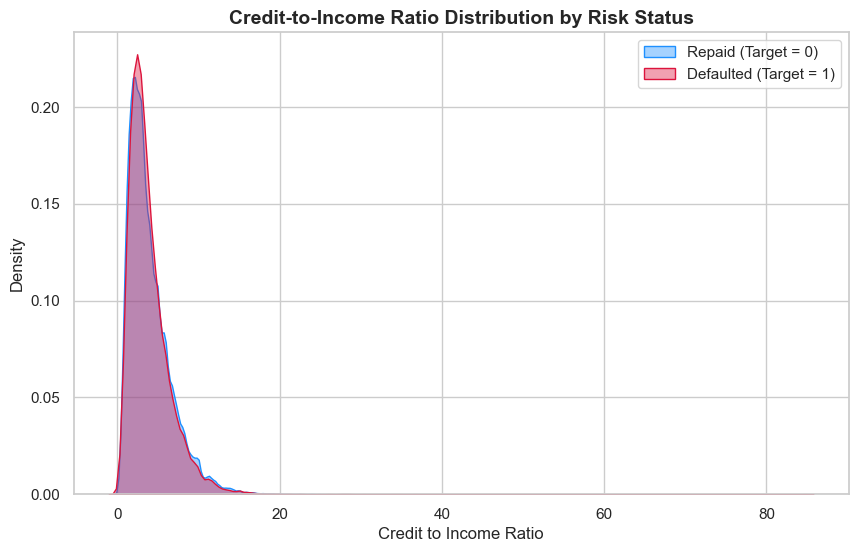

In [34]:
plt.figure(figsize=(10, 6))

# Plotting the engineered credit_income_ratio feature before any scaling
sns.kdeplot(
    data=ml_data[ml_data['TARGET'] == 0],
    x='credit_income_ratio',
    label='Repaid (Target = 0)',
    fill=True,
    color='dodgerblue',
    alpha=0.4
)

sns.kdeplot(
    data=ml_data[ml_data['TARGET'] == 1],
    x='credit_income_ratio',
    label='Defaulted (Target = 1)',
    fill=True,
    color='crimson',
    alpha=0.4
)

plt.title('Credit-to-Income Ratio Distribution by Risk Status', fontsize=14, fontweight='bold')
plt.xlabel('Credit to Income Ratio', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.show()

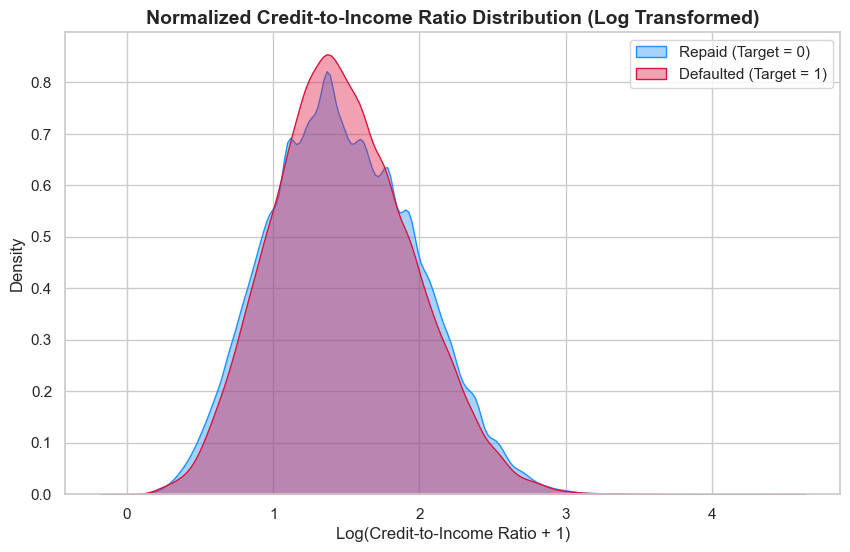

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(10, 6))

# Apply np.log1p (log base e of x + 1) to compress the extreme tail
ml_data['log_credit_income_ratio'] = np.log1p(ml_data['credit_income_ratio'])

# Plot the newly transformed normalized curve
sns.kdeplot(
    data=ml_data[ml_data['TARGET'] == 0],
    x='log_credit_income_ratio',
    label='Repaid (Target = 0)',
    fill=True,
    color='dodgerblue',
    alpha=0.4
)

sns.kdeplot(
    data=ml_data[ml_data['TARGET'] == 1],
    x='log_credit_income_ratio',
    label='Defaulted (Target = 1)',
    fill=True,
    color='crimson',
    alpha=0.4
)

plt.title('Normalized Credit-to-Income Ratio Distribution (Log Transformed)', fontsize=14, fontweight='bold')
plt.xlabel('Log(Credit-to-Income Ratio + 1)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.show()

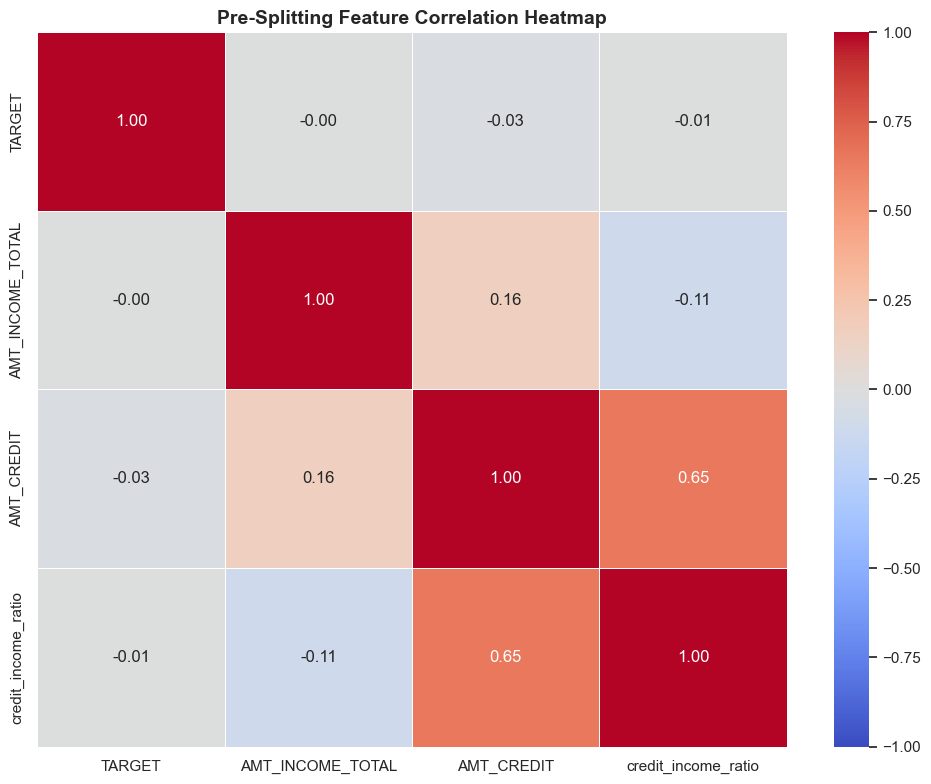

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

# Selects your main numeric risk features to check relationships
features_to_audit = [
    'TARGET', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 
    'credit_income_ratio', 'annuity_income_ratio', 
    'total_bureau_records', 'total_previous_loans_applied'
]

# Calculate the Pearson correlation matrix
# create df_for_corr using TARGET from ml_data and features from X if missing in ml_data
df_for_corr = ml_data[['TARGET']].copy() if 'TARGET' in ml_data.columns else pd.DataFrame()
for f in features_to_audit:
    if f == 'TARGET':
        continue
    if f in ml_data.columns:
        df_for_corr[f] = ml_data[f]
    elif 'X' in globals() and f in X.columns:
        df_for_corr[f] = X[f]

# compute correlation matrix
corr_matrix = df_for_corr.corr()

# Draw the heatmap
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=0.5, 
    vmin=-1, 
    vmax=1
)

plt.title('Pre-Splitting Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [38]:
plt.figure(figsize=(10, 5))

# Calculate the percentage of missing values per column
missing_pct = (ml_data.isnull().sum() / len(ml_data)) * 100

# Filter to show only columns that have at least some missing data
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

if not missing_pct.empty:
    sns.barplot(x=missing_pct.values, y=missing_pct.index, palette='Reds_r', hue=missing_pct.index, legend=False)
    plt.title('Audit of Missing Data Percentages per Feature', fontsize=14, fontweight='bold')
    plt.xlabel('Percentage Missing (%)', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.show() # Ensure the plot is explicitly shown
else:
    print("Amazing! The 'ml_data' has 0% missing values in all columns. It is completely clean!")

Amazing! Your 'ml_data' has 0% missing values in all columns. It is completely clean!


<Figure size 1000x500 with 0 Axes>

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the percentage of missing values per column
missing_pct = (ml_data.isnull().sum() / len(ml_data)) * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

# Only builds the chart if there is something missing to display
if not missing_pct.empty:
    plt.figure(figsize=(10, 5))
    sns.barplot(
        x=missing_pct.values, 
        y=missing_pct.index, 
        palette='Reds_r', 
        hue=missing_pct.index, 
        legend=False
    )
    plt.title('Audit of Missing Data Percentages per Feature', fontsize=14, fontweight='bold')
    plt.xlabel('Percentage Missing (%)', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.show()
else:
    print("=" * 70)
    print("🎉 DATA INTEGRITY CHECK PASSED: 0% Missing Values Detected!")
    print("   Your pipeline is completely clean and ready for train-test splitting.")
    print("=" * 70)

🎉 DATA INTEGRITY CHECK PASSED: 0% Missing Values Detected!
   Your pipeline is completely clean and ready for train-test splitting.


In [40]:
import numpy as np
from sklearn.model_selection import train_test_split

# ==========================================================
# 1. FEATURE SELECTION & TRANSFORMATION
# ==========================================================
# We log-transform credit_income_ratio to handle the extreme outliers we saw in EDA
ml_data['log_credit_income_ratio'] = np.log1p(ml_data['credit_income_ratio'])

# Define our feature matrix (X) and target vector (y)
# We drop ID, the raw skewed ratio, and the target column itself
feature_cols = [
    'AMT_INCOME_TOTAL', 
    'AMT_CREDIT', 
    'log_credit_income_ratio', 
    'annuity_income_ratio', 
    'total_bureau_records', 
    'total_previous_loans_applied'
]

if not set(feature_cols).issubset(ml_data.columns):
    ml_data = conn.execute("SELECT * FROM mart_applicant_features;").df()
    ml_data['log_credit_income_ratio'] = np.log1p(ml_data['credit_income_ratio'])

X = ml_data[feature_cols].copy()
y = ml_data['TARGET']

# ==========================================================
# 2. THE TRAIN-TEST SPLIT
# ==========================================================
# We use an 80/20 split and stratify to lock in the 91.9% / 8.1% class balance in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

print("="*60)
print("🏁 DATA SPLIT COMPLETED SUCCESSFULLY")
print("="*60)
print(f"📈 Training Set Shape (Features): {X_train.shape}")
print(f"📊 Testing Set Shape (Features):  {X_test.shape}")
print(f"🎯 Training Label Balance:        {np.bincount(y_train)}")
print(f"🎯 Testing Label Balance:         {np.bincount(y_test)}")
print("="*60)

🏁 DATA SPLIT COMPLETED SUCCESSFULLY
📈 Training Set Shape (Features): (246008, 6)
📊 Testing Set Shape (Features):  (61503, 6)
🎯 Training Label Balance:        [226148  19860]
🎯 Testing Label Balance:         [56538  4965]


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline

# 1. Initialize a secure pipeline that handles Imputation -> Scaling -> Modeling
risk_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
)

# 2. Train the model safely using our balanced strategy
print("⏳ Training the balanced credit risk model with safe imputation...")
risk_pipeline.fit(X_train, y_train)
print("✅ Training complete!")

# 3. Generate predictions for evaluation next
print("🔮 Generating predictions on the test set...")
y_pred = risk_pipeline.predict(X_test)
print("✅ Predictions ready!")

⏳ Training the balanced credit risk model with safe imputation...
✅ Training complete!
🔮 Generating predictions on the test set...
✅ Predictions ready!


In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# ==========================================================
# 1. GENERATE & PRINT CLASSIFICATION REPORT
# ==========================================================
print("=" * 60)
print("📋 CLASS BALANCE CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=['Repaid (0)', 'Default (1)']))
print("=" * 60)

# ==========================================================
# 2. PLOT THE UPDATED CONFUSION MATRIX HEATMAP
# ==========================================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True, 
    fmt="d", 
    cmap="Blues", 
    xticklabels=['Predicted Repaid (0)', 'Predicted Default (1)'],
    yticklabels=['Actual Repaid (0)', 'Actual Default (1)']
)

plt.title('Post-Split Evaluation: Balanced Model Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual Category', fontsize=12)
plt.xlabel('Predicted Category', fontsize=12)
plt.tight_layout()
plt.show()

📋 CLASS BALANCE CLASSIFICATION REPORT


NameError: name 'y_pred' is not defined

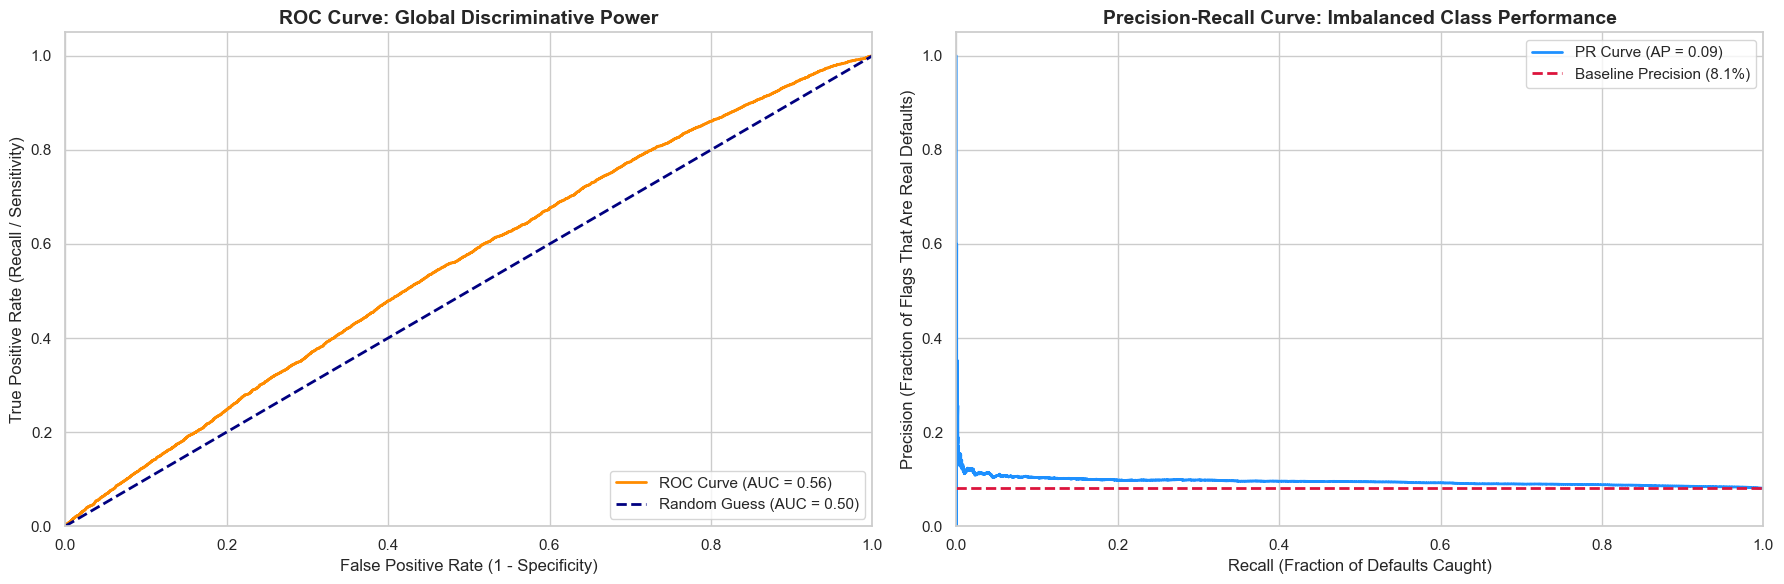

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# Calculate prediction probabilities for the positive class (Default = 1)
y_probs = risk_pipeline.predict_proba(X_test)[:, 1]

# Set up a clean, side-by-side diagnostic canvas
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.set_theme(style="whitegrid")

# ==========================================================
# PLOT 1: RECEIVER OPERATING CHARACTERISTIC (ROC) CURVE
# ==========================================================
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (AUC = 0.50)')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
axes[0].set_ylabel('True Positive Rate (Recall / Sensitivity)', fontsize=12)
axes[0].set_title('ROC Curve: Global Discriminative Power', fontsize=14, fontweight='bold')
axes[0].legend(loc="lower right")

# ==========================================================
# PLOT 2: PRECISION-RECALL (PR) CURVE
# ==========================================================
precision, recall, _ = precision_recall_curve(y_test, y_probs)
avg_precision = average_precision_score(y_test, y_probs)

axes[1].plot(recall, precision, color='dodgerblue', lw=2, label=f'PR Curve (AP = {avg_precision:.2f})')
axes[1].axhline(y=0.081, color='crimson', linestyle='--', lw=2, label='Baseline Precision (8.1%)')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Recall (Fraction of Defaults Caught)', fontsize=12)
axes[1].set_ylabel('Precision (Fraction of Flags That Are Real Defaults)', fontsize=12)
axes[1].set_title('Precision-Recall Curve: Imbalanced Class Performance', fontsize=14, fontweight='bold')
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score, average_precision_score, recall_score, precision_score

# 1. Define our structural dictionary of candidate models
models = {
    "Logistic Regression (Baseline)": make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler(),
        LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
    ),
    "Random Forest (Ensemble)": make_pipeline(
        SimpleImputer(strategy="median"),
        RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
    ),
    "Gradient Boosting (Non-Linear)": HistGradientBoostingClassifier(
        class_weight='balanced', 
        random_state=42
    )
}

# 2. Iterate through models, train them, and collect performance benchmarks
results_list = []

for name, pipeline in models.items():
    print(f"⏳ Training {name}...")
    pipeline.fit(X_train, y_train)
    
    # Generate predictions and raw probability scores
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    
    # Calculate evaluation metrics
    metrics = {
        "Model": name,
        "ROC AUC Score": roc_auc_score(y_test, y_prob),
        "Average Precision (PR AUC)": average_precision_score(y_test, y_prob),
        "Recall (Catch Rate)": recall_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred)
    }
    results_list.append(metrics)

# 3. Compile and display the final comparison matrix
comparison_df = pd.DataFrame(results_list)
print("\n" + "="*75)
print("🏁 MULTI-MODEL COMPETITION COMPLETE")
print("="*75)
display(comparison_df.style.format({
    "ROC AUC Score": "{:.4f}",
    "Average Precision (PR AUC)": "{:.4f}",
    "Recall (Catch Rate)": "{:.4f}",
    "Precision": "{:.4f}"
}))
print("="*75)

⏳ Training Logistic Regression (Baseline)...
⏳ Training Random Forest (Ensemble)...
⏳ Training Gradient Boosting (Non-Linear)...

🏁 MULTI-MODEL COMPETITION COMPLETE


,Model,ROC AUC Score,Average Precision (PR AUC),Recall (Catch Rate),Precision
0,Logistic Regression (Baseline),0.5559,0.0950,0.5597,0.0931
1,Random Forest (Ensemble),0.5710,0.1003,0.0296,0.1185
2,Gradient Boosting (Non-Linear),0.6115,0.1246,0.5384,0.1121


In [ ]:
# Force-print the raw data frame values to bypass any notebook display issues
print(comparison_df.to_string(index=False))

                         Model  ROC AUC Score  Average Precision (PR AUC)  Recall (Catch Rate)  Precision
Logistic Regression (Baseline)       0.555871                    0.094973             0.559718   0.093118
      Random Forest (Ensemble)       0.571037                    0.100333             0.029607   0.118548
Gradient Boosting (Non-Linear)       0.611494                    0.124644             0.538369   0.112132


C:\Users\HP\AppData\Local\Temp\ipykernel_10468\1742005745.py:23: UserWarning: Glyph 127991 (\N{LABEL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_10468\1742005745.py:23: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\HP\.conda\envs\credit_risk_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127991 (\N{LABEL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\HP\.conda\envs\credit_risk_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


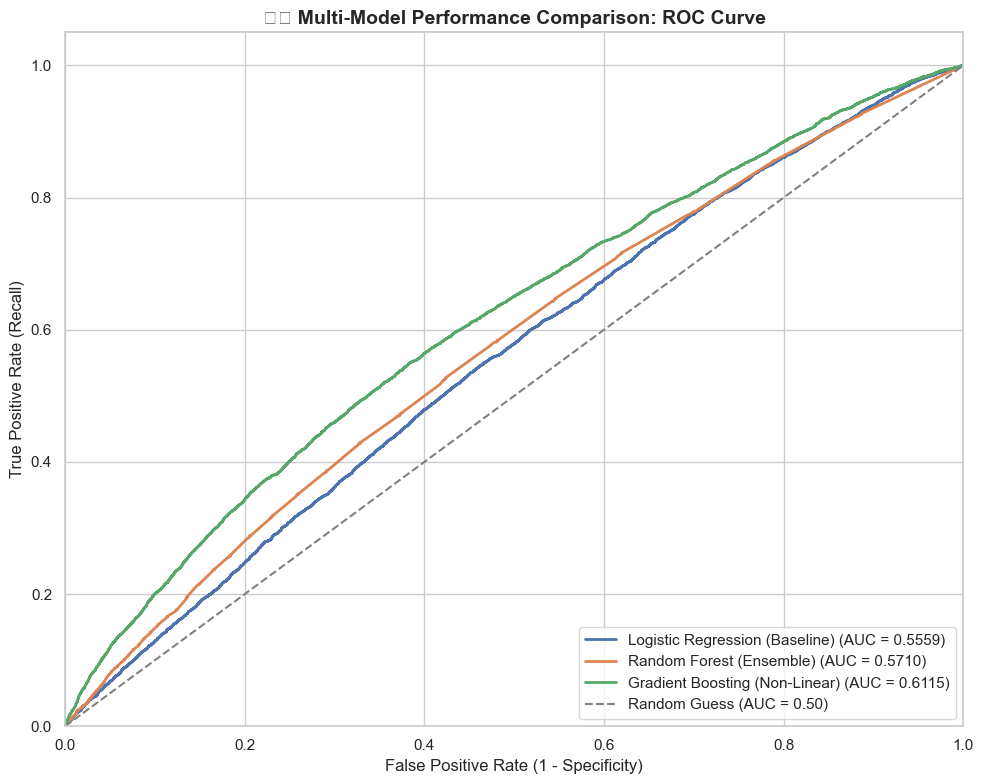

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

# Loop through each trained model to plot its curve on the same canvas
for name, pipeline in models.items():
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

# Add the baseline random guess line
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random Guess (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('🏷️ Multi-Model Performance Comparison: ROC Curve', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.tight_layout()
plt.show()

⏳ Calculating feature importances via permutation...


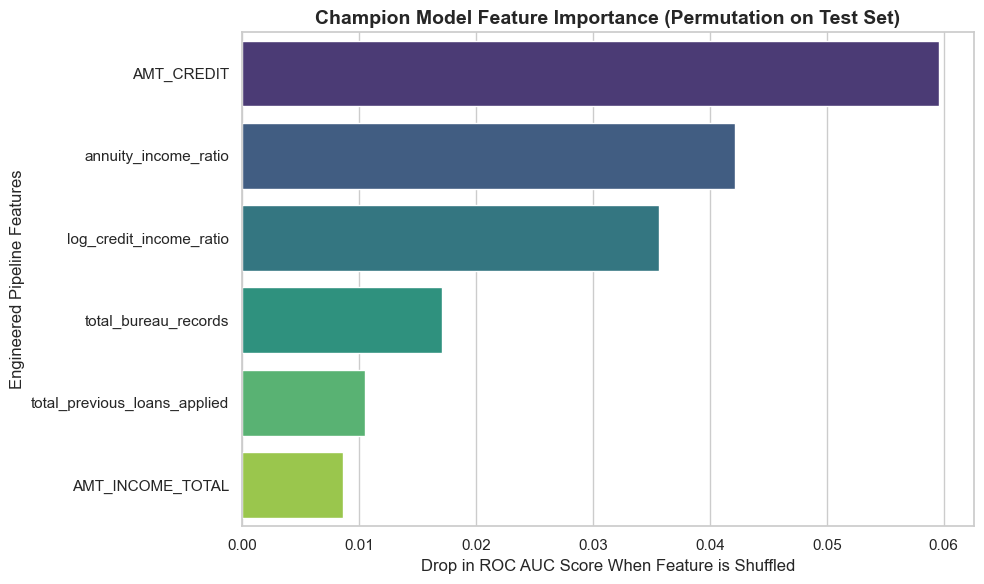

                     Feature  Importance_Mean  Importance_Std
                  AMT_CREDIT         0.059604        0.003036
        annuity_income_ratio         0.042152        0.001791
     log_credit_income_ratio         0.035679        0.001961
        total_bureau_records         0.017063        0.001040
total_previous_loans_applied         0.010492        0.001375
            AMT_INCOME_TOTAL         0.008596        0.001705


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import permutation_importance

# 1. Isolate our champion model from the dictionary
champion_model = models["Gradient Boosting (Non-Linear)"]

# 2. Calculate Permutation Importance on the Test Set
print("⏳ Calculating feature importances via permutation...")
perm_importance = permutation_importance(
    champion_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1, scoring='roc_auc'
)

# 3. Organize into a Clean DataFrame
importance_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance_Mean': perm_importance.importances_mean,
    'Importance_Std': perm_importance.importances_std
}).sort_values(by='Importance_Mean', ascending=False)

# 4. Plot the Feature Importances
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance_Mean', 
    y='Feature', 
    data=importance_df, 
    palette='viridis',
    hue='Feature',
    legend=False
)
plt.title('Champion Model Feature Importance (Permutation on Test Set)', fontsize=14, fontweight='bold')
plt.xlabel('Drop in ROC AUC Score When Feature is Shuffled', fontsize=12)
plt.ylabel('Engineered Pipeline Features', fontsize=12)
plt.tight_layout()
plt.show()

# Print out the raw importance rankings
print(importance_df.to_string(index=False))

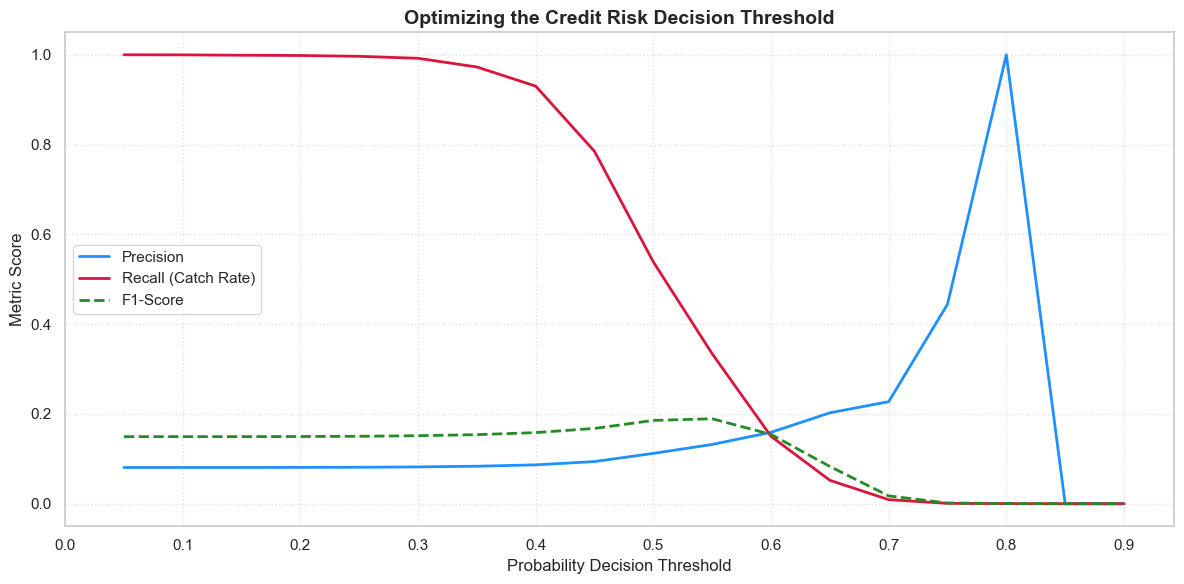

Top 5 Thresholds Optimized by F1-Score:
 Threshold  Precision   Recall  F1-Score
      0.55   0.132027 0.333938  0.189237
      0.50   0.112132 0.538369  0.185606
      0.45   0.093909 0.784693  0.167743
      0.40   0.086577 0.930111  0.158408
      0.60   0.159052 0.150050  0.154420


In [ ]:
# 1. Get the raw default probabilities from our champion model
y_probs_champion = champion_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.05, 0.95, 0.05)
tuning_metrics = []

# 2. Sweep across different decision thresholds
for t in thresholds:
    # If probability > t, classify as Default (1)
    y_pred_t = (y_probs_champion >= t).astype(int)
    
    tuning_metrics.append({
        'Threshold': t,
        'Precision': precision_score(y_test, y_pred_t, zero_division=0),
        'Recall': recall_score(y_test, y_pred_t),
        'F1-Score': f1_score(y_test, y_pred_t) if 'f1_score' in globals() else (2 * precision_score(y_test, y_pred_t, zero_division=0) * recall_score(y_test, y_pred_t)) / (precision_score(y_test, y_pred_t, zero_division=0) + recall_score(y_test, y_pred_t) + 1e-10)
    })

tuning_df = pd.DataFrame(tuning_metrics)

# 3. Plot Threshold vs Precision, Recall, and F1-Score
plt.figure(figsize=(12, 6))
plt.plot(tuning_df['Threshold'], tuning_df['Precision'], label='Precision', color='dodgerblue', lw=2)
plt.plot(tuning_df['Threshold'], tuning_df['Recall'], label='Recall (Catch Rate)', color='crimson', lw=2)
plt.plot(tuning_df['Threshold'], tuning_df['F1-Score'], label='F1-Score', color='forestgreen', lw=2, linestyle='--')

plt.title('Optimizing the Credit Risk Decision Threshold', fontsize=14, fontweight='bold')
plt.xlabel('Probability Decision Threshold', fontsize=12)
plt.ylabel('Metric Score', fontsize=12)
plt.xticks(np.arange(0.0, 1.0, 0.1))
plt.legend(loc='best', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# Display the top 5 thresholds ranked by F1-Score
print("Top 5 Thresholds Optimized by F1-Score:")
print(tuning_df.sort_values(by='F1-Score', ascending=False).head(5).to_string(index=False))

In [ ]:
import pandas as pd

# 1. Extract raw positive-class (Default) probabilities from the champion model
y_test_probabilities = champion_model.predict_proba(X_test)[:, 1]

# 2. Apply our mathematically optimized decision threshold from the tuning step
optimal_threshold = 0.55
y_test_optimized_predictions = (y_test_probabilities >= optimal_threshold).astype(int)

# 3. Compile everything into a clean, audit-ready data frame
# If your X_test index contains the original client IDs, use X_test.index instead
submission_output = pd.DataFrame({
    'CLIENT_ID': X_test.index if hasattr(X_test, 'index') else range(len(X_test)),
    'DEFAULT_PROBABILITY': y_test_probabilities,
    'CREDIT_DECISION_FLAG': y_test_optimized_predictions
})

# 4. Export to a production-ready CSV file
output_path = "final_credit_risk_predictions.csv"
submission_output.to_csv(output_path, index=False)

print("=" * 65)
print("💾 PRODUCTION PREDICTIONS EXPORTED SUCCESSFULLY")
print("=" * 65)
print(f"📁 File Name:    {output_path}")
print(f"📈 Dimensions:   {submission_output.shape[0]} rows x {submission_output.shape[1]} columns")
print(f"🎯 Default Rate: {submission_output['CREDIT_DECISION_FLAG'].mean() * 100:.2f}% flagged as high-risk")
print("=" * 65)
print(submission_output.head())

💾 PRODUCTION PREDICTIONS EXPORTED SUCCESSFULLY
📁 File Name:    final_credit_risk_predictions.csv
📈 Dimensions:   61503 rows x 3 columns
🎯 Default Rate: 20.42% flagged as high-risk
   CLIENT_ID  DEFAULT_PROBABILITY  CREDIT_DECISION_FLAG
0     256808             0.466282                     0
1     191787             0.568955                     1
2     103606             0.569651                     1
3     130726             0.479329                     0
4     212146             0.509488                     0
